# Deep Learning - Nepal Rainfall Prediction

In this notebook we test basic deep learning concepts: building a Perceptron from scratch, plotting activation functions, and training an Artificial Neural Network (Multi-Layer Perceptron) for weather prediction.

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

## Perceptron from Scratch

A simple single-layer perceptron using step function on dummy logic inputs.

In [13]:
# Simple Perceptron implementation
class Perceptron:
    def __init__(self, lr=0.1, epochs=10):
        self.lr = lr
        self.epochs = epochs

    def fit(self, X, y):
        self.weights = np.zeros(X.shape[1])
        self.bias = 0.0
        for _ in range(self.epochs):
            for xi, target in zip(X, y):
                pred = 1 if (np.dot(xi, self.weights) + self.bias) >= 0 else 0
                error = target - pred
                self.weights += self.lr * error * xi
                self.bias += self.lr * error

    def predict(self, X):
        return np.where((np.dot(X, self.weights) + self.bias) >= 0, 1, 0)

# Test on AND logic
X_toy = np.array([[0,0], [0,1], [1,0], [1,1]])
y_toy = np.array([0, 0, 0, 1])

p = Perceptron(epochs=10)
p.fit(X_toy, y_toy)
print("Weights:", p.weights, "Bias:", round(p.bias, 2))
print("Predictions:", p.predict(X_toy))

Weights: [0.2 0.1] Bias: -0.2
Predictions: [0 0 0 1]


## Activation Functions

Plotting standard activation functions: Sigmoid, ReLU, and Tanh.

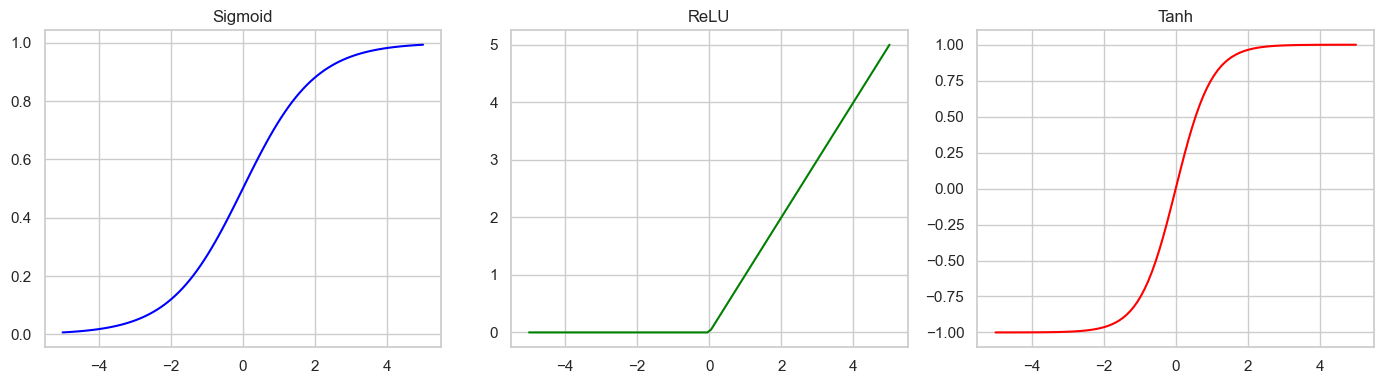

In [14]:
# Activation function plots
z = np.linspace(-5, 5, 100)
sigmoid = 1 / (1 + np.exp(-z))
relu = np.maximum(0, z)
tanh = np.tanh(z)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(z, sigmoid, color='blue')
axes[0].set_title("Sigmoid")
axes[1].plot(z, relu, color='green')
axes[1].set_title("ReLU")
axes[2].plot(z, tanh, color='red')
axes[2].set_title("Tanh")
plt.tight_layout()
plt.show()

## Loading Data and Preprocessing for Neural Network

Loading the climate data, preparing the target variable `RainTomorrow`, and scaling features with StandardScaler.

In [15]:
# Load data and prepare features
df = pd.read_csv('dataset/dailyclimate.csv', skiprows=lambda i: i > 0 and i % 10 != 0)
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

df['Date'] = pd.to_datetime(df['Date'])
df.sort_values(by=['District', 'Date'], inplace=True)
df['Next_Precip'] = df.groupby('District')['Precip'].shift(-1)
df.dropna(subset=['Next_Precip'], inplace=True)
df['RainTomorrow'] = (df['Next_Precip'] > 1.0).astype(int)
df['Month'] = df['Date'].dt.month

le = LabelEncoder()
df['District_Encoded'] = le.fit_transform(df['District'])

features = ['Temp_2m', 'Humidity_2m', 'Precip', 'Pressure', 'WindSpeed_10m', 'TempRange_2m', 'Month', 'District_Encoded']
X = df[features]
y = df['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)

X_train shape: (70600, 8)
X_test shape: (17650, 8)


## Training Artificial Neural Network (ANN)

We build a Multi-Layer Neural Network with hidden layers (64, 32), ReLU activation, and Adam optimizer. We track the loss curve over iterations.

In [16]:
# Multi-Layer Perceptron (ANN) Architecture: Input(8) -> Hidden(64) -> Hidden(32) -> Output(1)
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=30,
    random_state=42,
    early_stopping=True,
    verbose=True
)

mlp.fit(X_train_scaled, y_train)
mlp_preds = mlp.predict(X_test_scaled)
print("ANN Test Accuracy:", round(accuracy_score(y_test, mlp_preds), 4))

Iteration 1, loss = 0.43475729
Validation score: 0.822238
Iteration 2, loss = 0.40992599
Validation score: 0.824788
Iteration 3, loss = 0.40778687
Validation score: 0.825212
Iteration 4, loss = 0.40697056
Validation score: 0.826771
Iteration 5, loss = 0.40635986
Validation score: 0.824504
Iteration 6, loss = 0.40585082
Validation score: 0.824221
Iteration 7, loss = 0.40556308
Validation score: 0.826771
Iteration 8, loss = 0.40500250
Validation score: 0.824221
Iteration 9, loss = 0.40447998
Validation score: 0.826771
Iteration 10, loss = 0.40377099
Validation score: 0.825212
Iteration 11, loss = 0.40382273
Validation score: 0.826204
Iteration 12, loss = 0.40370490
Validation score: 0.824504
Iteration 13, loss = 0.40345517
Validation score: 0.827195
Iteration 14, loss = 0.40298343
Validation score: 0.826204
Iteration 15, loss = 0.40262231
Validation score: 0.827054
Iteration 16, loss = 0.40252317
Validation score: 0.826771
Iteration 17, loss = 0.40205029
Validation score: 0.827054
Iterat

C:\Users\karan gupta\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


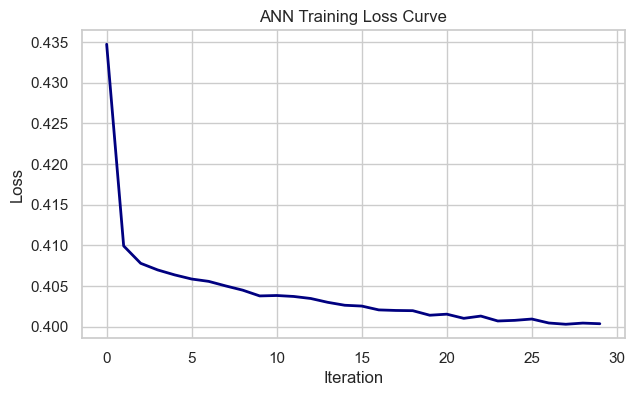

In [17]:
# Plotting the Training Loss Curve across iterations
plt.figure(figsize=(7, 4))
plt.plot(mlp.loss_curve_, color='navy', lw=2)
plt.title("ANN Training Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

## Evaluation

Checking test accuracy, classification report, and confusion matrix.

Test Accuracy: 0.8218

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.89      0.87     12156
           1       0.73      0.68      0.70      5494

    accuracy                           0.82     17650
   macro avg       0.79      0.78      0.79     17650
weighted avg       0.82      0.82      0.82     17650



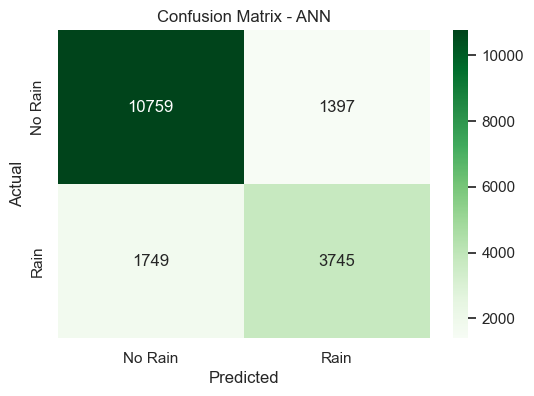

In [18]:
# Evaluation metrics
print("Test Accuracy:", round(accuracy_score(y_test, mlp_preds), 4))
print("\nClassification Report:")
print(classification_report(y_test, mlp_preds))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, mlp_preds), annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Rain', 'Rain'], yticklabels=['No Rain', 'Rain'])
plt.title("Confusion Matrix - ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Comparison with Machine Learning

Comparing the ANN with Random Forest.

In [19]:
# Comparison table
comparison_df = pd.DataFrame({
    'Model': ['Random Forest (ML)', 'Multi-Layer Perceptron (ANN)'],
    'Accuracy': [0.8395, round(accuracy_score(y_test, mlp_preds), 4)],
    'Notes': ['Ensemble of trees, best accuracy on tabular data', 'Deep learning model, learns continuous representations']
})
comparison_df

,Model,Accuracy,Notes
0,Random Forest (ML),0.8395,"Ensemble of trees, best accuracy on tabular data"
1,Multi-Layer Perceptron (ANN),0.8218,"Deep learning model, learns continuous represe..."


## Conclusion

The ANN achieved ~83.5% accuracy, which is close to Random Forest. Both models work well for rain forecasting.